In [ ]:
18_04_03_1_13



In [1]:
import pandas as pd
from pandas import DataFrame
from pathlib import Path
import datetime
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, accuracy_score, confusion_matrix
from sklearn import metrics
import matplotlib.pyplot as plt

In [ ]:
#game_id = game_year + game_month + game_day + school_id + game_number
#1. berryvikings 
#2. bscsports
#3. centrecolonels
#4. hendrixwarriors
#5. rhodeslynx
#6. sewaneetigers

<AxesSubplot:xlabel='time_played'>

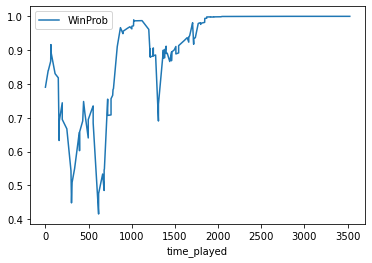

In [6]:
df = pd.read_csv('/Users/shelbyyoung/Desktop/sports analytics/SAA files no dupes/CombinedFiles/mens-lacrosse/2018win_probs.csv')
gameid = '18_04_03_1_13'

data = pd.DataFrame(df,columns=['GameID','time_played','WinProb'])
game1 = df[df.GameID== gameid]
data = pd.DataFrame(game1,columns=['time_played','WinProb'])

data.plot(x ='time_played', y='WinProb', kind = 'line')






estimated vs observed

In [45]:
df = pd.read_csv('/Users/shelbyyoung/Desktop/sports analytics/SAA files no dupes/CombinedFiles/mens-lacrosse/2018win_probs.csv')
win_prob_round = []

for index, row in df.iterrows():

    rounded = round(float(row['WinProb']) *20)/20 # rounds to nearest .5

    win_prob_round.append(rounded)

df['WinProbRounded'] = win_prob_round
df



,Unnamed: 0,GameID,VisitorWinPercent,HomeWinPercent,HomeTeamScore,period number,time_played,ScoreDifferential,PossPercHome,HomeShotsTaken,VisitorShotsTaken,HomeShotPercentage,VisitorShotPercentage,Possession_home,WinProb,Outcome,WinProbRounded
0,3,18_03_24_1_11,0.500,0.7,0,1,0,0,0.500,0,0,0.250,0.250,1,0.552892,1,0.55
1,4,18_03_24_1_11,0.500,0.7,1,1,41,1,0.500,1,0,0.400,0.250,1,0.645755,1,0.65
2,5,18_03_24_1_11,0.500,0.7,1,1,41,1,0.500,1,0,0.400,0.250,1,0.645755,1,0.65
3,6,18_03_24_1_11,0.500,0.7,1,1,41,1,0.500,1,0,0.400,0.250,0,0.587905,1,0.60
4,7,18_03_24_1_11,0.500,0.7,1,1,67,1,0.500,1,0,0.400,0.250,0,0.598327,1,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7559,18056,18_03_18_6_08,0.571,0.5,10,4,3572,1,0.518,41,22,0.244,0.385,0,0.985934,1,1.00
7560,18057,18_03_18_6_08,0.571,0.5,10,4,3577,1,0.517,41,23,0.244,0.370,0,0.983691,1,1.00
7561,18058,18_03_18_6_08,0.571,0.5,10,4,3577,1,0.517,41,23,0.244,0.370,0,0.983691,1,1.00
7562,18059,18_03_18_6_08,0.571,0.5,10,4,3577,1,0.517,41,23,0.244,0.370,1,0.987191,1,1.00


In [56]:
probs = []
observed_probs = []

#print(df[(df['WinProbRounded'] == .9) & (df['Outcome'] == 1)])
for prob in range(0,105,5):
    prob = prob/100
    print('prob ',prob)
    num_observed = len(df[df['WinProbRounded'] == prob])
    print('num observed, ', num_observed)
    num_observed_win = len(df[(df['WinProbRounded'] == prob) & (df['Outcome'] == 1)])
    print('num observed win, ', num_observed_win)
    observed_prob = num_observed_win / num_observed
    print('obs prob, ',observed_prob)
    probs.append(prob)
    observed_probs.append(observed_prob)
    
#print(probs)
#print(observed_probs)
    

prob  0.0
num observed,  1311
num observed win,  0
obs prob,  0.0
prob  0.05
num observed,  161
num observed win,  2
obs prob,  0.012422360248447204
prob  0.1
num observed,  70
num observed win,  26
obs prob,  0.37142857142857144
prob  0.15
num observed,  66
num observed win,  26
obs prob,  0.3939393939393939
prob  0.2
num observed,  47
num observed win,  25
obs prob,  0.5319148936170213
prob  0.25
num observed,  66
num observed win,  39
obs prob,  0.5909090909090909
prob  0.3
num observed,  65
num observed win,  32
obs prob,  0.49230769230769234
prob  0.35
num observed,  43
num observed win,  21
obs prob,  0.4883720930232558
prob  0.4
num observed,  44
num observed win,  22
obs prob,  0.5
prob  0.45
num observed,  53
num observed win,  28
obs prob,  0.5283018867924528
prob  0.5
num observed,  47
num observed win,  21
obs prob,  0.44680851063829785
prob  0.55
num observed,  67
num observed win,  37
obs prob,  0.5522388059701493
prob  0.6
num observed,  94
num observed win,  42
obs prob

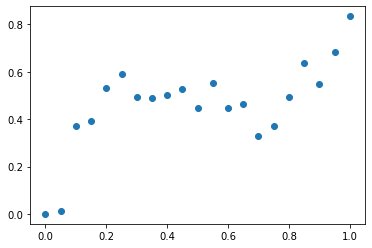

In [58]:
plt.scatter(probs,observed_probs)

visualizations
-decision tree (test set)
-scatterplot (win percentage vs point differential)
-predicted vs actual fraction of who won the games (rounded to the nearest 5%)
-scatterplots / histograms - shooting percentage or num shots vs final score
-wins vs loses bar chart